# MUSIN-G Dataset Loader Demo

This notebook demonstrates how to use the BCMIMusingLoader to load the MUSIN-G dataset,
which contains EEG recordings from 20 subjects listening to 12 different songs.

## Dataset Overview
- **Subjects**: 20
- **Songs**: 12 (various genres)
- **Sessions**: 12 per subject (one per song)
- **Sampling Rate**: 250 Hz
- **Format**: BIDS-compliant EEGLAB .set files
- **Music IDs**: Integer from 0 to 11 (MusingMusicId)

In [1]:
from pathlib import Path
import sys

# Add parent directory to path if needed
project_root = Path.cwd()
# if str(project_root) not in sys.path:
#     sys.path.insert(0, str(project_root))

from eeg_music.bcmi import BCMIMusingLoader, create_bcmi_loader
from eeg_music.data import MusingMusicId, MusicFilename, copy_from_dataloader_into_dir
from eeg_music.data import EEGMusicDataset

/home/zmrocze/studia/uwr/eeg-magisterka/.devenv/state/venv/lib/python3.12/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()


In [2]:
from pathlib import Path
from eeg_music.data import EEGMusicDataset

ds = EEGMusicDataset.load_ondisk(Path("./datasets/musin_g_export2"))

## 1. Load MUSIN-G Dataset with BCMIMusingLoader

We can use either the specific loader class or the factory function.

In [3]:
# Path to the musin-g dataset
musin_g_path = Path(".") / "datasets" / "musin_g_data"

# Method 1: Direct instantiation
loader = BCMIMusingLoader(str(musin_g_path))

# Method 2: Using factory function (automatically detects dataset type)
# loader = create_bcmi_loader(str(musin_g_path))

print(f"Dataset: {loader.dataset_name}")
print(f"Number of subjects: {len(loader.subjects)}")
print(f"Subjects: {loader.subjects[:5]}...")  # Show first 5

Dataset: musin-g
Number of subjects: 20
Subjects: ['001', '002', '003', '004', '005']...


In [4]:
# loader_export = BCMIMusingLoader(str(musin_g_path))
# loader_export.load_all_subjects()
new_dataset_save_dir = Path("./datasets/musin_g_export2")
# copy_from_dataloader_into_dir(loader_export, new_dataset_save_dir)

ds = EEGMusicDataset.load_ondisk(new_dataset_save_dir)

In [5]:
import matplotlib.pyplot as plt

s = set()
for t in ds:
  l = t.eeg_data.get_eeg().length_seconds()
  s.add(l)

plt.hist(list(s), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Length of EEG snippets (seconds)')
plt.ylabel('Count')
plt.title('Histogram of EEG Snippet Lengths')
plt.grid(True)
plt.show()


KeyboardInterrupt: 

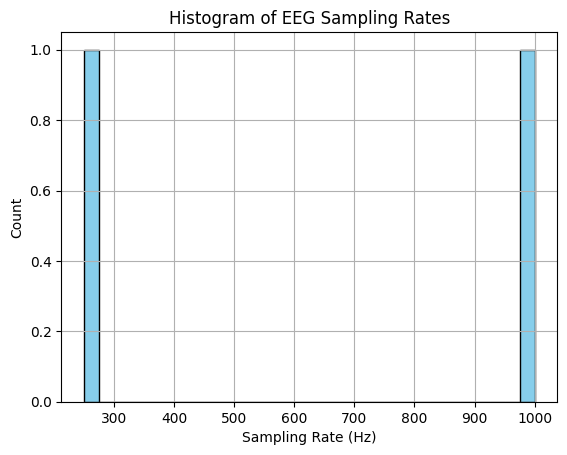

In [ ]:
import matplotlib.pyplot as plt

s = set()
for t in ds:
  sr = t.eeg_data.get_eeg().raw_eeg.info['sfreq']
  s.add(sr)

plt.hist(list(s), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Sampling Rate (Hz)')
plt.ylabel('Count')
plt.title('Histogram of EEG Sampling Rates')
plt.grid(True)
plt.show()


In [ ]:
ds[0].eeg_data.get_eeg().raw_eeg.ch_names

['E1',
 'E2',
 'E3',
 'E4',
 'E5',
 'E6',
 'E7',
 'E8',
 'E9',
 'E10',
 'E11',
 'E12',
 'E13',
 'E14',
 'E15',
 'E16',
 'E17',
 'E18',
 'E19',
 'E20',
 'E21',
 'E22',
 'E23',
 'E24',
 'E25',
 'E26',
 'E27',
 'E28',
 'E29',
 'E30',
 'E31',
 'E32',
 'E33',
 'E34',
 'E35',
 'E36',
 'E37',
 'E38',
 'E39',
 'E40',
 'E41',
 'E42',
 'E43',
 'E44',
 'E45',
 'E46',
 'E47',
 'E48',
 'E49',
 'E50',
 'E51',
 'E52',
 'E53',
 'E54',
 'E55',
 'E56',
 'E57',
 'E58',
 'E59',
 'E60',
 'E61',
 'E62',
 'E63',
 'E64',
 'E65',
 'E66',
 'E67',
 'E68',
 'E69',
 'E70',
 'E71',
 'E72',
 'E73',
 'E74',
 'E75',
 'E76',
 'E77',
 'E78',
 'E79',
 'E80',
 'E81',
 'E82',
 'E83',
 'E84',
 'E85',
 'E86',
 'E87',
 'E88',
 'E89',
 'E90',
 'E91',
 'E92',
 'E93',
 'E94',
 'E95',
 'E96',
 'E97',
 'E98',
 'E99',
 'E100',
 'E101',
 'E102',
 'E103',
 'E104',
 'E105',
 'E106',
 'E107',
 'E108',
 'E109',
 'E110',
 'E111',
 'E112',
 'E113',
 'E114',
 'E115',
 'E116',
 'E117',
 'E118',
 'E119',
 'E120',
 'E121',
 'E122',
 'E123',
 

240

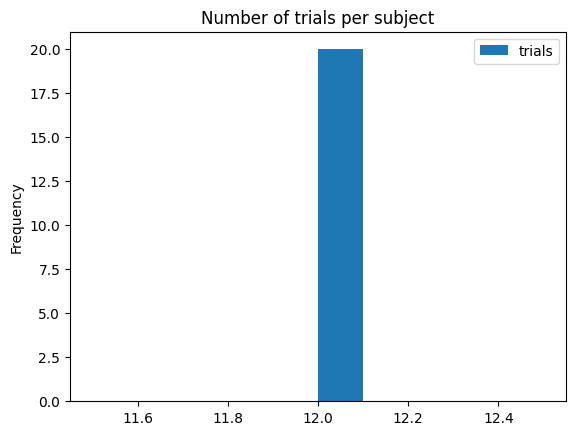

In [ ]:
subject_trials = ds.df.groupby(level=['subject']).size().reset_index(name='trials')
subject_trials.plot(kind='hist', title='Number of trials per subject')

len(ds.df)

In [ ]:
from eeg_music.data import MappedDataset
from eeg_music.onset_conversion import trial_wavraw_to_noteonsets
from eeg_music.eegpt import USING_CHANNELS
from eeg_music.data import prepare_trial
from eeg_music.data import rereference_trial

# some_channels = ["F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6", "T7", "C3", "Cz", "C4", "T8", "CP5", "CP6", "P7", "P8"]
# less_some_channels = ["F7", "Fz", "FC1", "FC6", "T7", "Cz", "CP5", "P8"]
# minimal_channels = ["Fz", "T7", "Cz", "T8"]

# less_some_channels = ["E11" , "E18", "E19", "E33", "E45", "E47", "E96", "E116"]

mapped = MappedDataset(ds, lambda x: 
  # rereference_trial(
      prepare_trial(
        x,
        eeg_resample=1000,
        eeg_l_freq=1.0,
        eeg_h_freq=50.0,
        # pick_channels=less_some_channels, # 8 channels
      ) # type: ignore
    # )  
  )

print(mapped[0])

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 825 samples (3.300 s)

TrialData(
  dataset=musin-g, subject=001, session=01, run=1, trial_id=song_01,
  music_filename=song_01.wav,
  eeg=RawEeg(sfreq=1000, chans=129, secs=136.999, samples=136999),
  music=MusingMusicIdData
)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 825 samples (3.300 s)

Sampling frequency of the instance is already 250.0, returning unmodified.


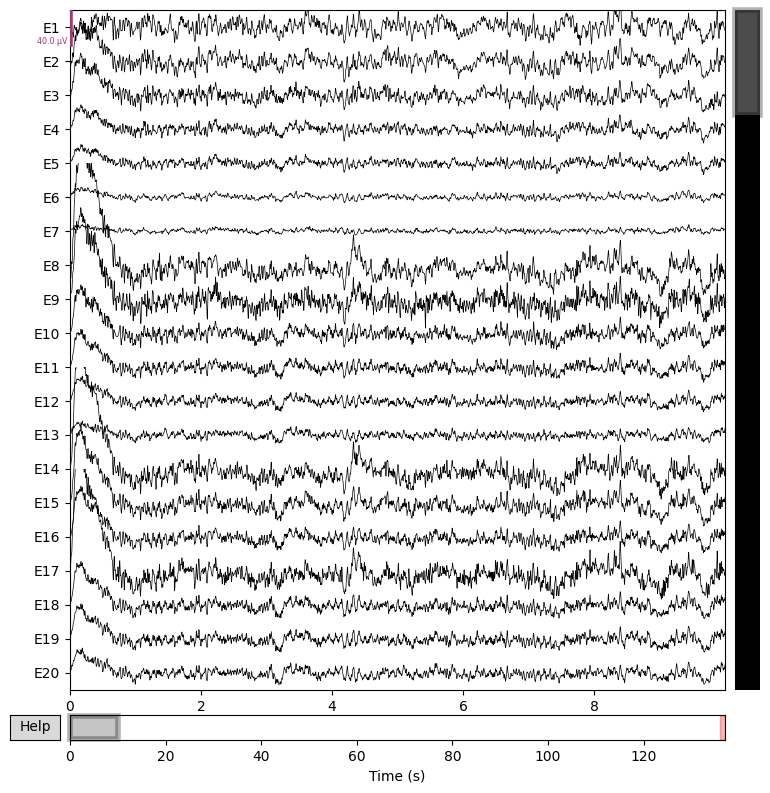

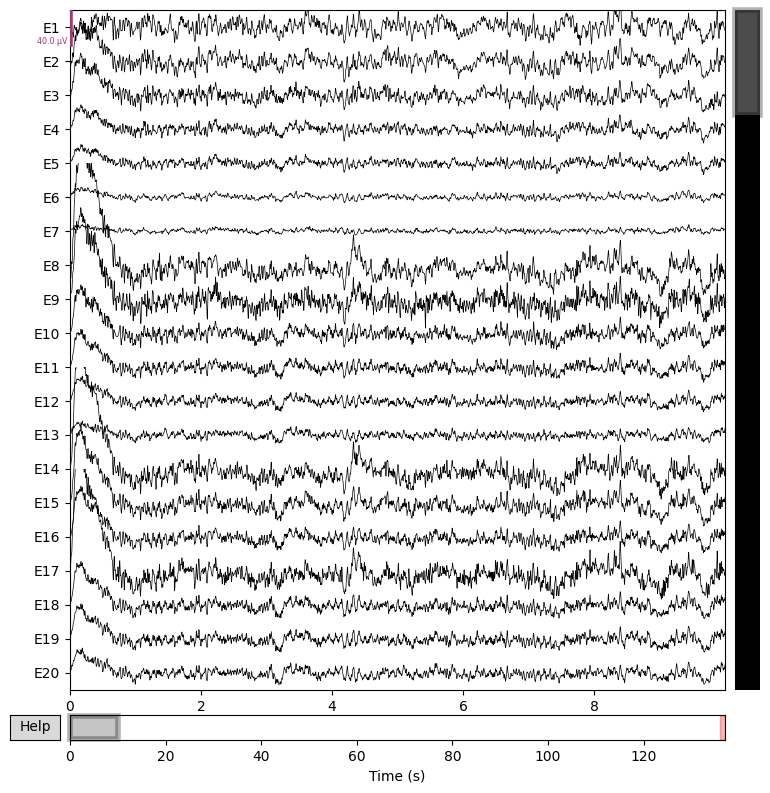

In [ ]:
mapped[0].eeg_data.get_eeg().raw_eeg.plot()

In [ ]:
from eeg_music.band_power_calc import calculate_band_power
bp = calculate_band_power(mapped[3].eeg_data.get_eeg().raw_eeg, bands=[('delta', 0.5, 4), ('theta', 4, 8), ('alpha', 8, 13), ('beta', 13, 30), ('gamma', 30, 45)])

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 825 samples (3.300 s)

Effective window size : 0.256 (s)


In [ ]:
# dict str: np.array
bp_concat[4]

array([1.83952143e-11, 7.80571130e-12, 1.04722452e-11, 1.76447875e-12,
       1.75438431e-13, 2.27448602e-11, 2.26076686e-11, 2.26611045e-10,
       3.97088426e-11, 1.50383289e-13, 2.32870923e-11, 2.92792161e-14,
       4.39093328e-14, 3.03549037e-11, 9.39193594e-12, 9.97702429e-14,
       9.53492544e-11, 3.06525803e-12, 2.48464103e-11, 1.85358251e-11,
       5.66509601e-12, 1.48201803e-11, 3.08051270e-12, 1.09111957e-13,
       4.66570893e-11, 1.28929181e-12, 1.92969522e-12, 9.05651048e-13,
       7.07189190e-12, 4.60100006e-13, 5.54968042e-13, 9.57656527e-13,
       4.45634116e-12, 1.54885295e-11, 1.43373681e-11, 9.35218425e-12,
       7.69853449e-14, 3.16429881e-13, 1.36309653e-11, 6.29453377e-11,
       6.24928853e-11, 7.04623126e-11, 1.53442397e-13, 8.14035036e-11,
       3.55361054e-11, 5.85090067e-11, 5.52915965e-11, 1.35736375e-11,
       1.06500776e-11, 5.63216745e-11, 4.94653926e-11, 4.59304215e-11,
       8.54392679e-12, 7.25561964e-13, 4.15538534e-12, 2.72924297e-11,
      

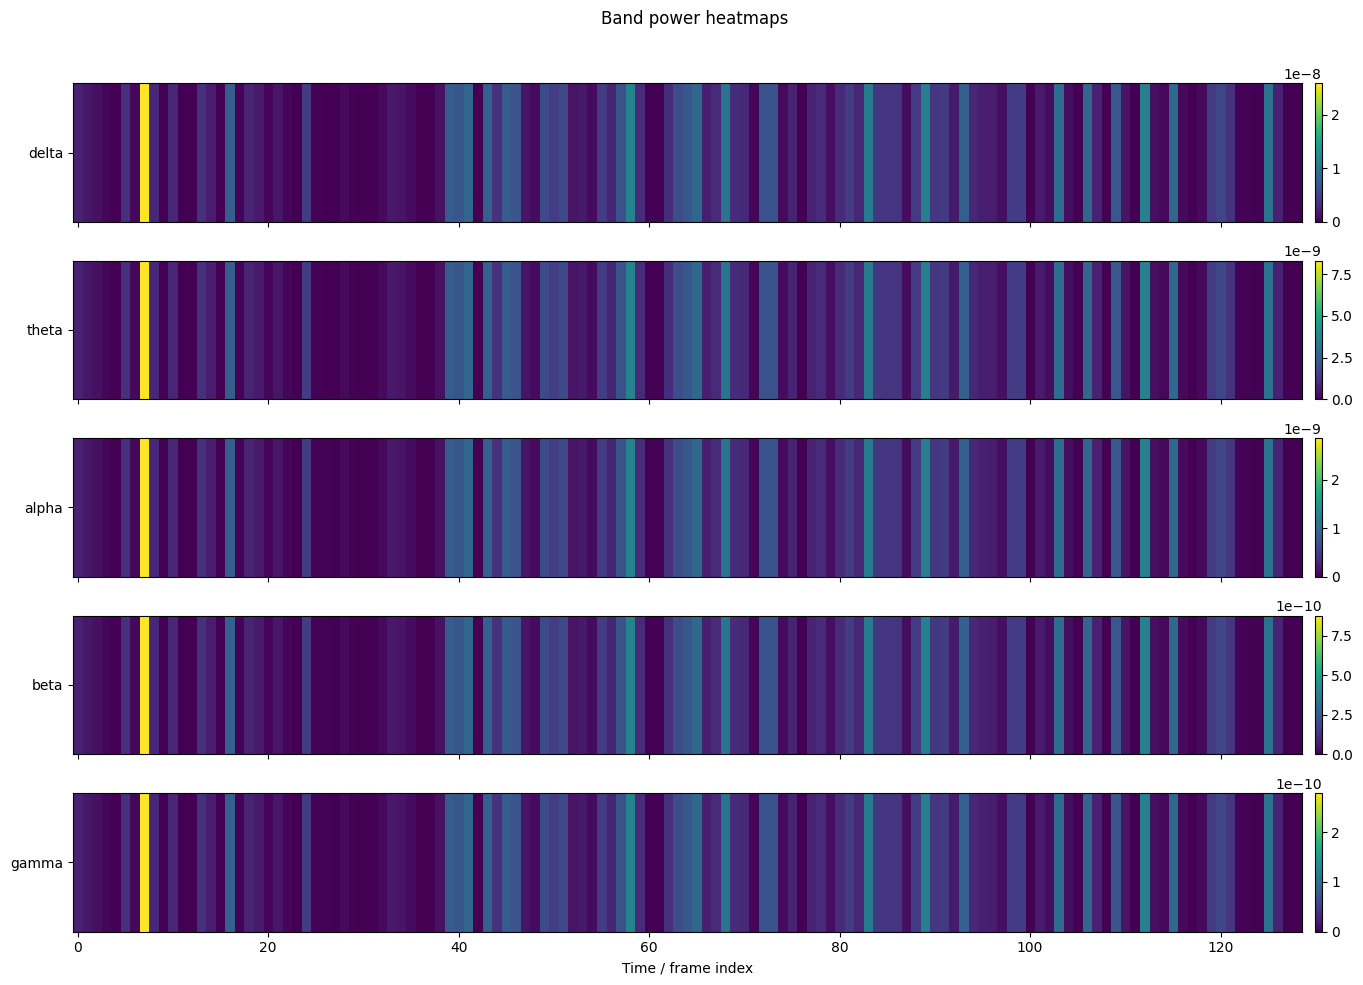

In [ ]:
# plot every band in bp as a stacked heatmap
bands_list = list(bp.keys())
n = len(bands_list)
fig, axs = plt.subplots(n, 1, figsize=(14, 2 * n), sharex=True)
for i, band in enumerate(bands_list):
  ax = axs[i] if n > 1 else axs
  data = bp[band][None, :]  # shape (1, T)
  im = ax.imshow(data, aspect='auto', origin='lower', cmap='viridis')
  ax.set_yticks([0])
  ax.set_yticklabels([band])
  if i == n - 1:
    ax.set_xlabel('Time / frame index')
  fig.colorbar(im, ax=ax, orientation='vertical', pad=0.01, fraction=0.05)
fig.suptitle('Band power heatmaps')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
from eeg_music.band_power import trial_to_band_power, BandPowerParams

band_power_ds = MappedDataset(
  mapped,
  trial_to_band_power(
    BandPowerParams(
      frequency_bands=[(1, 4), (4, 8), (8, 12), (12, 30), (30, 45)],
      window_width=1000,
      hop_length=100,
    )
  )
)

In [ ]:
ar = band_power_ds[0].eeg_data.get_array()

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 825 samples (3.300 s)



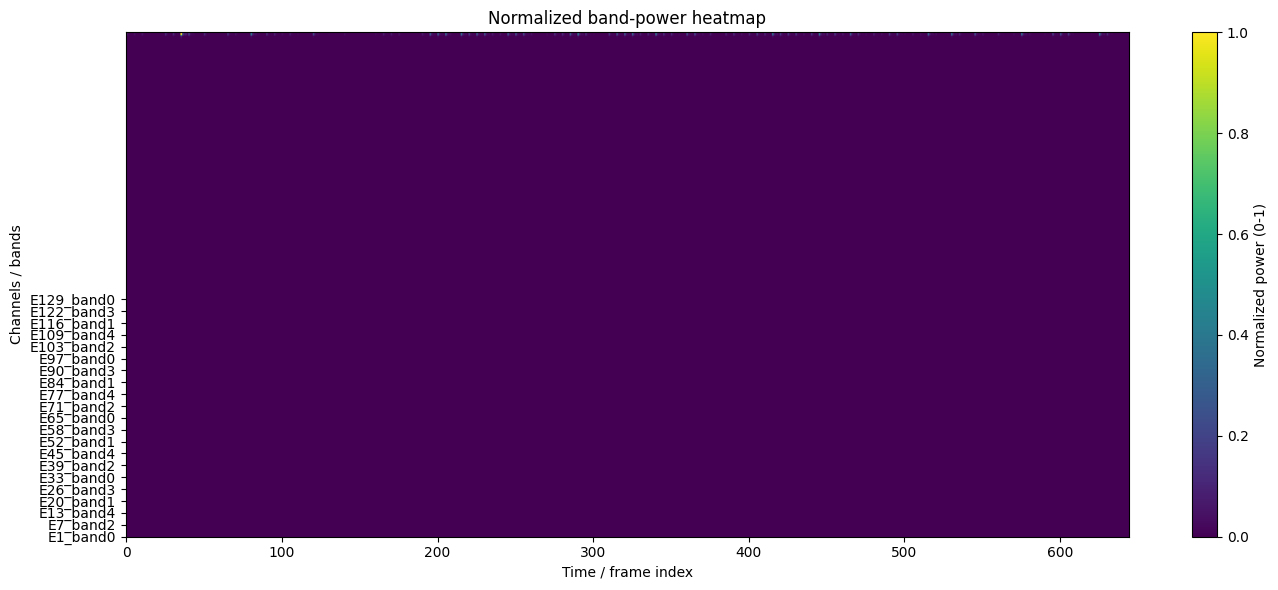

In [ ]:
# normalize to 0-1 (min-max) and plot heatmap
import matplotlib.pyplot as plt

data = ar.data.astype(float)
minv, maxv = data.min(), data.max()
norm = (data - minv) / (maxv - minv) if maxv > minv else data * 0.0

plt.figure(figsize=(14, 6))
# transpose so channels are on the y-axis (more readable)
plt.imshow(norm.T, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='Normalized power (0-1)')
plt.xlabel('Time / frame index')
plt.ylabel('Channels / bands')

ch_names = ar.ch_names
if len(ch_names) <= 60:
  plt.yticks(range(len(ch_names)), ch_names)
else:
  step = max(1, len(ch_names) // 20)
  plt.yticks(range(0, len(ch_names), step), [ch_names[i] for i in range(0, len(ch_names), step)])

plt.title('Normalized band-power heatmap')
plt.tight_layout()
plt.show()

1.0

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 825 samples (3.300 s)



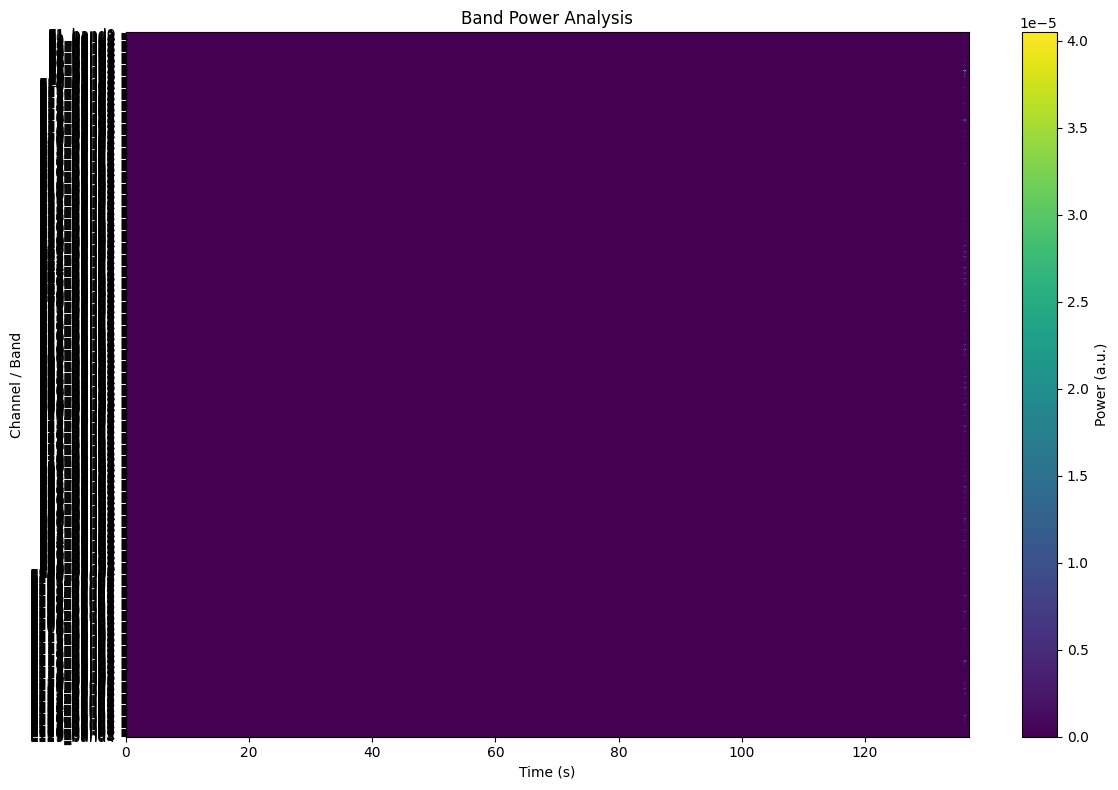

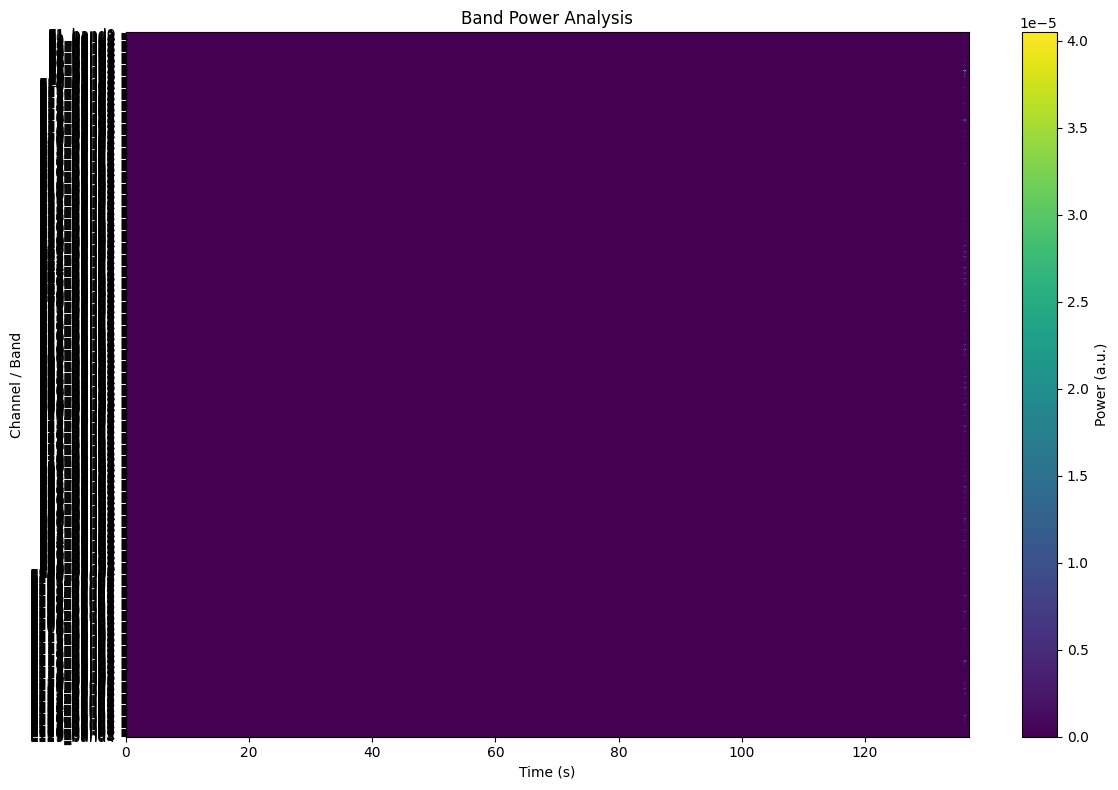

In [ ]:
from eeg_music.plotting import plot_band_power_with_onsets
plot_band_power_with_onsets(band_power_ds[0])

In [ ]:
mapped.save(Path("./datasets/musing_preprocessed/musing_8ch"))

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1651 samples (6.604 s)

Sampling frequency of the instance is already 250.0, returning unmodified.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transitio

/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/data.py:493: RuntimeWarning: EDF format requires equal-length data blocks, so 0.004 seconds of edge values were appended to all channels when writing the final block.
  mne.export.export_raw(filepath, self.raw_eeg, fmt="edf", overwrite=True)


Sampling frequency of the instance is already 250.0, returning unmodified.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1651 samples (6.604 s)



/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/data.py:493: RuntimeWarning: EDF format requires equal-length data blocks, so 0.004 seconds of edge values were appended to all channels when writing the final block.
  mne.export.export_raw(filepath, self.raw_eeg, fmt="edf", overwrite=True)


Sampling frequency of the instance is already 250.0, returning unmodified.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1651 samples (6.604 s)

Sampling frequency of the instance is already 250.0, returning unmodified.


...

/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/data.py:493: RuntimeWarning: EDF format requires equal-length data blocks, so 0.004 seconds of edge values were appended to all channels when writing the final block.
  mne.export.export_raw(filepath, self.raw_eeg, fmt="edf", overwrite=True)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 6601 samples (6.601 s)



/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/data.py:493: RuntimeWarning: EDF format requires equal-length data blocks, so 0.004 seconds of edge values were appended to all channels when writing the final block.
  mne.export.export_raw(filepath, self.raw_eeg, fmt="edf", overwrite=True)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 6601 samples (6.601 s)



/home/zmrocze/studia/uwr/eeg-magisterka/src/eeg_music/data.py:493: RuntimeWarning: EDF format requires equal-length data blocks, so 0.004 seconds of edge values were appended to all channels when writing the final block.
  mne.export.export_raw(filepath, self.raw_eeg, fmt="edf", overwrite=True)


In [ ]:
import matplotlib.pyplot as plt

s = set()
ll = set()
for t in mapped:
  sr = t.eeg_data.get_eeg().raw_eeg.info['sfreq']
  l = t.eeg_data.get_eeg().length_seconds()
  ch = t.eeg_data.get_eeg().raw_eeg.get_data().shape[1]
  s.add(sr)
  ll.add(l)

plt.hist(list(s), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Sampling Rate (Hz)')
plt.ylabel('Count')
plt.title('Histogram of EEG Sampling Rates')
plt.grid(True)
plt.show()

plt.hist(list(ll), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Length (s)')
plt.ylabel('Count')
plt.title('Histogram of EEG Lengths')
plt.grid(True)
plt.show()


## 7. Load Exported Dataset with EegMusicDataset

After exporting, we can load the dataset using EegMusicDataset.

In [ ]:
# Assuming you've exported the dataset in step 6
# exported_path = output_dir

# Load with EegMusicDataset
# dataset = EegMusicDataset(base_dir=exported_path)
# print(f"Loaded {len(dataset)} trials")

# Access a trial
# trial = dataset[0]
# print(f"\nFirst trial:")
# print(trial.pretty())

## 8. Access Behavioral Data

The MUSIN-G dataset includes behavioral ratings (enjoyment and familiarity) in the stimuli directory.

In [ ]:
import pandas as pd

# Load behavioral data
behavioral_file = musin_g_path / "stimuli" / "Behavioural_data"
behavioral_df = pd.read_csv(behavioral_file, sep="\t")

print("Behavioral data columns:", behavioral_df.columns.tolist())
print(f"\nShape: {behavioral_df.shape}")
print("\nFirst few rows:")
print(behavioral_df.head(10))

# Get ratings for subject 1, song 1
subject_1_song_1 = behavioral_df[(behavioral_df['Subject'] == 1) & (behavioral_df['Song_ID'] == 1)]
if not subject_1_song_1.empty:
    enjoyment = subject_1_song_1['Enjoyment'].iloc[0]
    familiarity = subject_1_song_1['Familiarity'].iloc[0]
    print(f"\nSubject 1, Song 1:")
    print(f"  Enjoyment: {enjoyment}/5")
    print(f"  Familiarity: {familiarity}/5")

## 9. Song Information

The musing.py module contains detailed information about all 12 songs.

In [ ]:
from eeg_music.musing import songs_info_enhanced

print("\nSong Information:")
print("=" * 80)
for song_id, info in songs_info_enhanced.items():
    print(f"\nSong {song_id}: {info['name']}")
    print(f"  Artist: {info['artist']}")
    print(f"  Genre: {info['genre']}")
    print(f"  Duration: {info['duration']}s")
    print(f"  Tempo: {info['tempo']} BPM" if info['tempo'] else "  Tempo: N/A")
    print(f"  Characteristics: {info['characteristics']}")

## Summary

This notebook demonstrated:

1. **Loading MUSIN-G dataset** with `BCMIMusingLoader`
2. **Understanding `MusingMusicId`** type (integers 1-12 for 12 songs)
3. **Accessing EEG data** for subjects and sessions
4. **Iterating over trials** with `trial_iterator()`
5. **Exporting dataset** with `copy_from_dataloader_into_dir()`
6. **Loading exported data** with `EegMusicDataset`
7. **Accessing behavioral ratings** (enjoyment and familiarity)
8. **Song metadata** from the musing module

### Key Features of MUSIN-G Loader:

- **Compatible with BCMI framework**: Extends `BaseBCMILoader`
- **BIDS format support**: Uses mne_bids for loading
- **Session-based organization**: Each of 12 sessions represents one song
- **Full song trials**: Each trial contains the complete EEG recording for one song
- **No audio files**: The dataset contains only EEG data and metadata
- **Behavioral data**: Ratings available separately in stimuli directory